# 약물 수요 예측 프로젝트 - Step 1: EDA
**분석 범위**: 서울시 25개 구 / 2023년 10월 ~ 2025년 10월 (25개월)  
**분석 약물**: A10A (인슐린 및 유사체), A10B (인슐린 제외 혈당강하제)

In [1]:
%matplotlib inline
"""
약물 수요 예측 프로젝트 - Step 1: EDA (탐색적 데이터 분석)
"""

import pandas as pd
import numpy as np
import matplotlib

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 경로 설정
DATA_DIR = 'dataset'
FIG_DIR = 'output/figures'
os.makedirs(FIG_DIR, exist_ok=True)

# ─────────────────────────────────────────────
# 유틸 함수
# ─────────────────────────────────────────────

def parse_atc_sigungu(filepath):
    """
    ATC 시군구별 엑셀(멀티헤더) → tidy DataFrame 변환
    컬럼 구조: [ATC코드, ATC코드명, 시도명칭, 시군구명칭, (수량, 금액) x 25개월]
    """
    df_raw = pd.read_excel(filepath, header=None)

    # 행 2: 기간, 행 3: 실제 헤더
    period_row = df_raw.iloc[2].tolist()   # 년월 정보
    header_row = df_raw.iloc[3].tolist()   # 수량/금액 반복

    # 고정 컬럼: 0=ATC코드, 1=ATC코드명, 2=시도명칭, 3=시군구명칭
    fixed_cols = ['ATC코드', 'ATC코드명', '시도명칭', '시군구명칭']

    # 기간별 (수량, 금액) 컬럼 인덱스 추출
    records = []
    current_period = None
    col_pairs = []  # (기간, 수량_idx, 금액_idx)
    i = 4
    while i < len(period_row):
        val = period_row[i]
        if isinstance(val, str) and '년' in val:
            current_period = val.strip()
        if current_period and isinstance(header_row[i], str) and '수량' in header_row[i]:
            qty_idx = i
            amt_idx = i + 1 if i + 1 < len(header_row) else None
            col_pairs.append((current_period, qty_idx, amt_idx))
        i += 1

    # 데이터 행 (4행부터), '계' 행 제외
    df_data = df_raw.iloc[4:].copy()
    df_data = df_data[df_data.iloc[:, 0] != '계'].reset_index(drop=True)

    # Long 형태로 변환
    for period, qty_idx, amt_idx in col_pairs:
        temp = pd.DataFrame()
        temp['ATC코드'] = df_data.iloc[:, 0]
        temp['ATC코드명'] = df_data.iloc[:, 1]
        temp['시도명칭'] = df_data.iloc[:, 2]
        temp['시군구명칭'] = df_data.iloc[:, 3]
        temp['기간'] = period
        temp['수량'] = pd.to_numeric(df_data.iloc[:, qty_idx], errors='coerce')
        if amt_idx is not None:
            temp['금액'] = pd.to_numeric(df_data.iloc[:, amt_idx], errors='coerce')
        else:
            temp['금액'] = np.nan
        records.append(temp)

    df_long = pd.concat(records, ignore_index=True)
    df_long['기간_dt'] = pd.to_datetime(df_long['기간'].str.replace('년 ', '-').str.replace('월', ''), format='%Y-%m')
    df_long = df_long.dropna(subset=['수량'])
    return df_long


def parse_atc_sigungu_yoyanggi(filepath):
    """
    ATC 시군구별_요양기관종별 엑셀 → tidy DataFrame
    고정 컬럼: ATC코드, ATC코드명, 시도명칭, 시군구명칭, 요양기관종별
    """
    df_raw = pd.read_excel(filepath, header=None)
    period_row = df_raw.iloc[2].tolist()
    header_row = df_raw.iloc[3].tolist()

    col_pairs = []
    current_period = None
    i = 5  # 요양기관종별 컬럼이 추가됨
    while i < len(period_row):
        val = period_row[i]
        if isinstance(val, str) and '년' in val:
            current_period = val.strip()
        if current_period and isinstance(header_row[i], str) and '수량' in header_row[i]:
            col_pairs.append((current_period, i, i + 1))
        i += 1

    df_data = df_raw.iloc[4:].copy()
    df_data = df_data[df_data.iloc[:, 0] != '계'].reset_index(drop=True)

    records = []
    for period, qty_idx, amt_idx in col_pairs:
        temp = pd.DataFrame()
        temp['ATC코드'] = df_data.iloc[:, 0]
        temp['ATC코드명'] = df_data.iloc[:, 1]
        temp['시도명칭'] = df_data.iloc[:, 2]
        temp['시군구명칭'] = df_data.iloc[:, 3]
        temp['요양기관종별'] = df_data.iloc[:, 4]
        temp['기간'] = period
        temp['수량'] = pd.to_numeric(df_data.iloc[:, qty_idx], errors='coerce')
        temp['금액'] = pd.to_numeric(df_data.iloc[:, amt_idx], errors='coerce')
        records.append(temp)

    df_long = pd.concat(records, ignore_index=True)
    df_long['기간_dt'] = pd.to_datetime(df_long['기간'].str.replace('년 ', '-').str.replace('월', ''), format='%Y-%m')
    df_long = df_long.dropna(subset=['수량'])
    return df_long


def parse_atc_sangbyeong(filepath):
    """
    ATC 상병별 엑셀 → tidy DataFrame
    컬럼: 기간, ATC코드, ATC코드명, 상병코드, 상병명, 순위, 수량, 금액
    """
    df_raw = pd.read_excel(filepath, header=None)
    # 행 2가 실제 헤더
    df = df_raw.iloc[3:].copy()
    df.columns = ['기간', 'ATC코드', 'ATC코드명', '상병코드', '상병명', '순위', '수량', '금액']
    df = df.reset_index(drop=True)
    df['수량'] = pd.to_numeric(df['수량'], errors='coerce')
    df['금액'] = pd.to_numeric(df['금액'], errors='coerce')
    df['순위'] = pd.to_numeric(df['순위'], errors='coerce')
    df['기간_dt'] = pd.to_datetime(df['기간'].str.replace('년 ', '-').str.replace('월', ''), format='%Y-%m')
    df = df.dropna(subset=['수량'])
    return df


def parse_population(filepath):
    """주민등록 인구 및 세대현황 파싱"""
    df_raw = pd.read_excel(filepath, header=None)
    df = df_raw.iloc[2:].copy()
    df.columns = ['행정기관코드', '행정기관', '총거주자수', '세대수', '세대당인구', '남자인구수', '여자인구수', '남여비율']
    df = df.reset_index(drop=True)
    for col in ['총거주자수', '세대수', '세대당인구', '남자인구수', '여자인구수', '남여비율']:
        df[col] = df[col].astype(str).str.replace(',', '').str.strip()
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.dropna(subset=['총거주자수'])
    return df


def parse_age_population(filepath):
    """연령별 인구현황 파싱"""
    df_raw = pd.read_excel(filepath, header=None)
    # 행 3이 실제 헤더
    header = df_raw.iloc[3].tolist()
    df = df_raw.iloc[4:].copy()
    df.columns = range(len(df.columns))
    # 필요한 컬럼만 추출: 행정기관코드(0), 행정기관(1), 총거주자수(2), 60~69(9), 70~79(10), 80~89(11), 90~99(12), 100세이상(13)
    df_age = pd.DataFrame()
    df_age['행정기관코드'] = df.iloc[:, 0]
    df_age['행정기관'] = df.iloc[:, 1]
    df_age['총거주자수'] = df.iloc[:, 2].astype(str).str.replace(',', '').pipe(pd.to_numeric, errors='coerce')
    df_age['연령구간인구수'] = df.iloc[:, 3].astype(str).str.replace(',', '').pipe(pd.to_numeric, errors='coerce')
    # 연령대 컬럼 (총계 기준): 인덱스 4~13
    age_labels = ['0~9세', '10~19세', '20~29세', '30~39세', '40~49세', '50~59세', '60~69세', '70~79세', '80~89세', '90~99세', '100세이상']
    for i, label in enumerate(age_labels):
        df_age[label] = df.iloc[:, 4 + i].astype(str).str.replace(',', '').pipe(pd.to_numeric, errors='coerce')
    df_age = df_age.dropna(subset=['총거주자수'])
    # 고령인구비율 (60세 이상)
    elderly_cols = ['60~69세', '70~79세', '80~89세', '90~99세', '100세이상']
    df_age['고령인구수'] = df_age[elderly_cols].sum(axis=1)
    df_age['고령인구비율'] = df_age['고령인구수'] / df_age['총거주자수']
    return df_age

## Step 1. 데이터 로드 및 기본 검사

In [2]:
print("=" * 60)
print("Step 1. 데이터 로드 및 기본 검사")
print("=" * 60)

# A10A 데이터
print("\n[A10A] 시군구별 로드 중...")
df_a10a = parse_atc_sigungu(f'{DATA_DIR}/ATC코드3단계의_시군구별_202310_202510.xlsx')
print(f"  shape: {df_a10a.shape}")
print(f"  기간 범위: {df_a10a['기간_dt'].min()} ~ {df_a10a['기간_dt'].max()}")
print(f"  시군구 수: {df_a10a['시군구명칭'].nunique()}")
print(f"  결측치:\n{df_a10a.isnull().sum()}")

# A10B 데이터
print("\n[A10B] 시군구별 로드 중...")
df_a10b = parse_atc_sigungu(f'{DATA_DIR}/B_ATC코드3단계의_시군구별_202310_202510.xlsx')
print(f"  shape: {df_a10b.shape}")
print(f"  기간 범위: {df_a10b['기간_dt'].min()} ~ {df_a10b['기간_dt'].max()}")
print(f"  시군구 수: {df_a10b['시군구명칭'].nunique()}")

# 요양기관종별
print("\n[A10A] 요양기관종별 로드 중...")
df_a10a_yoy = parse_atc_sigungu_yoyanggi(f'{DATA_DIR}/ATC코드3단계의_시군구별_요양기관종별_202310_202510.xlsx')
print(f"  shape: {df_a10a_yoy.shape}")
print(f"  요양기관 종류: {df_a10a_yoy['요양기관종별'].unique()}")

print("\n[A10B] 요양기관종별 로드 중...")
df_a10b_yoy = parse_atc_sigungu_yoyanggi(f'{DATA_DIR}/B_ATC코드3단계의_시군구별_요양기관종별_202310_202510.xlsx')
print(f"  shape: {df_a10b_yoy.shape}")

# 상병별
print("\n[A10A] 상병별 로드 중...")
df_a10a_sb = parse_atc_sangbyeong(f'{DATA_DIR}/ATC코드3단계의_상병별_202310_202510.xlsx')
print(f"  shape: {df_a10a_sb.shape}")
print(f"  상병 수: {df_a10a_sb['상병코드'].nunique()}")

print("\n[A10B] 상병별 로드 중...")
df_a10b_sb = parse_atc_sangbyeong(f'{DATA_DIR}/B_ATC코드3단계의_상병별_202310_202510.xlsx')
print(f"  shape: {df_a10b_sb.shape}")
print(f"  상병 수: {df_a10b_sb['상병코드'].nunique()}")

# 인구 데이터
print("\n[인구] 주민등록 인구 로드 중...")
df_pop = parse_population(f'{DATA_DIR}/202510_202510_주민등록인구및세대현황_월간.xlsx')
print(f"  shape: {df_pop.shape}")

print("\n[인구] 연령별 인구 로드 중...")
df_age = parse_age_population(f'{DATA_DIR}/202510_202510_연령별인구현황_월간.xlsx')
print(f"  shape: {df_age.shape}")
print(f"  고령인구비율 통계:\n{df_age['고령인구비율'].describe()}")

print("\n[완료] 모든 파일 로드 완료")

Step 1. 데이터 로드 및 기본 검사

[A10A] 시군구별 로드 중...
  shape: (625, 8)
  기간 범위: 2023-10-01 00:00:00 ~ 2025-10-01 00:00:00
  시군구 수: 25
  결측치:
ATC코드     0
ATC코드명    0
시도명칭      0
시군구명칭     0
기간        0
수량        0
금액        0
기간_dt     0
dtype: int64

[A10B] 시군구별 로드 중...
  shape: (625, 8)
  기간 범위: 2023-10-01 00:00:00 ~ 2025-10-01 00:00:00
  시군구 수: 25

[A10A] 요양기관종별 로드 중...
  shape: (625, 9)
  요양기관 종류: ['의원']

[A10B] 요양기관종별 로드 중...
  shape: (625, 9)

[A10A] 상병별 로드 중...
  shape: (2500, 9)
  상병 수: 142

[A10B] 상병별 로드 중...
  shape: (2500, 9)
  상병 수: 117

[인구] 주민등록 인구 로드 중...
  shape: (26, 8)

[인구] 연령별 인구 로드 중...
  shape: (26, 17)
  고령인구비율 통계:
count    26.000000
mean      0.279028
std       0.030857
min       0.227009
25%       0.259885
50%       0.274483
75%       0.298890
max       0.349977
Name: 고령인구비율, dtype: float64

[완료] 모든 파일 로드 완료


## Step 2. 시계열 추세 분석


Step 2. 시계열 추세 분석


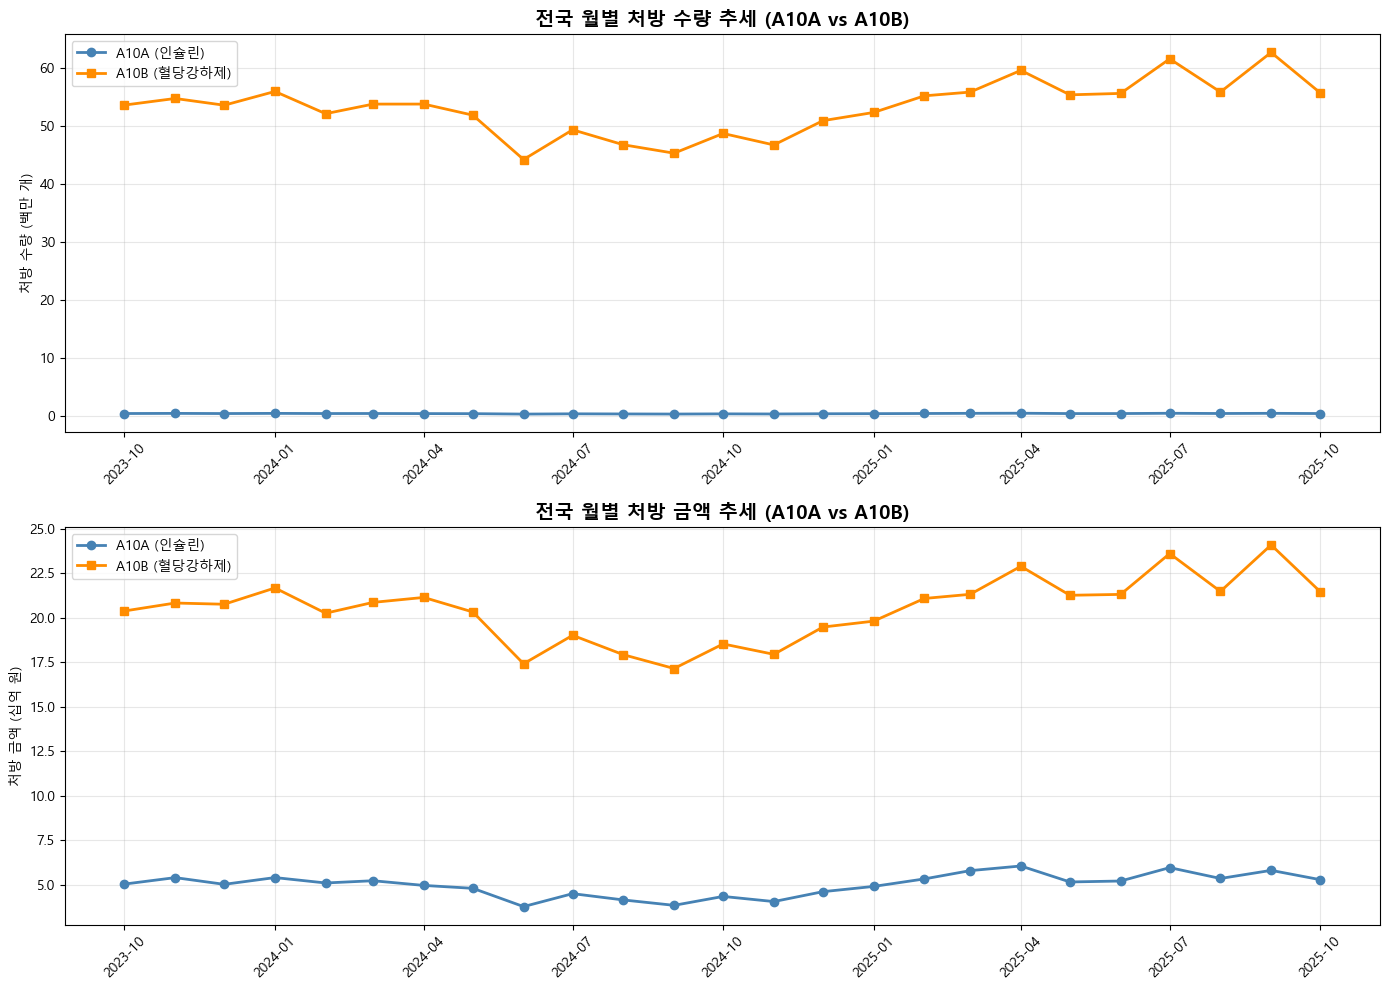

  저장: output/figures/01_monthly_trend.png


In [3]:
print("\n" + "=" * 60)
print("Step 2. 시계열 추세 분석")
print("=" * 60)

# 전국 월별 합계
monthly_a10a = df_a10a.groupby('기간_dt')[['수량', '금액']].sum().reset_index()
monthly_a10b = df_a10b.groupby('기간_dt')[['수량', '금액']].sum().reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 수량 추세
ax1 = axes[0]
ax1.plot(monthly_a10a['기간_dt'], monthly_a10a['수량'] / 1e6, marker='o', label='A10A (인슐린)', color='steelblue', linewidth=2)
ax1.plot(monthly_a10b['기간_dt'], monthly_a10b['수량'] / 1e6, marker='s', label='A10B (혈당강하제)', color='darkorange', linewidth=2)
ax1.set_title('전국 월별 처방 수량 추세 (A10A vs A10B)', fontsize=14, fontweight='bold')
ax1.set_ylabel('처방 수량 (백만 개)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%Y-%m'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# 금액 추세
ax2 = axes[1]
ax2.plot(monthly_a10a['기간_dt'], monthly_a10a['금액'] / 1e9, marker='o', label='A10A (인슐린)', color='steelblue', linewidth=2)
ax2.plot(monthly_a10b['기간_dt'], monthly_a10b['금액'] / 1e9, marker='s', label='A10B (혈당강하제)', color='darkorange', linewidth=2)
ax2.set_title('전국 월별 처방 금액 추세 (A10A vs A10B)', fontsize=14, fontweight='bold')
ax2.set_ylabel('처방 금액 (십억 원)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%Y-%m'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
path = f'{FIG_DIR}/01_monthly_trend.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f"  저장: {path}")

## Step 3. 구별 처방량 분포 (서울 25개 구)


Step 3. 구별 처방량 분포 (서울 25개 구)


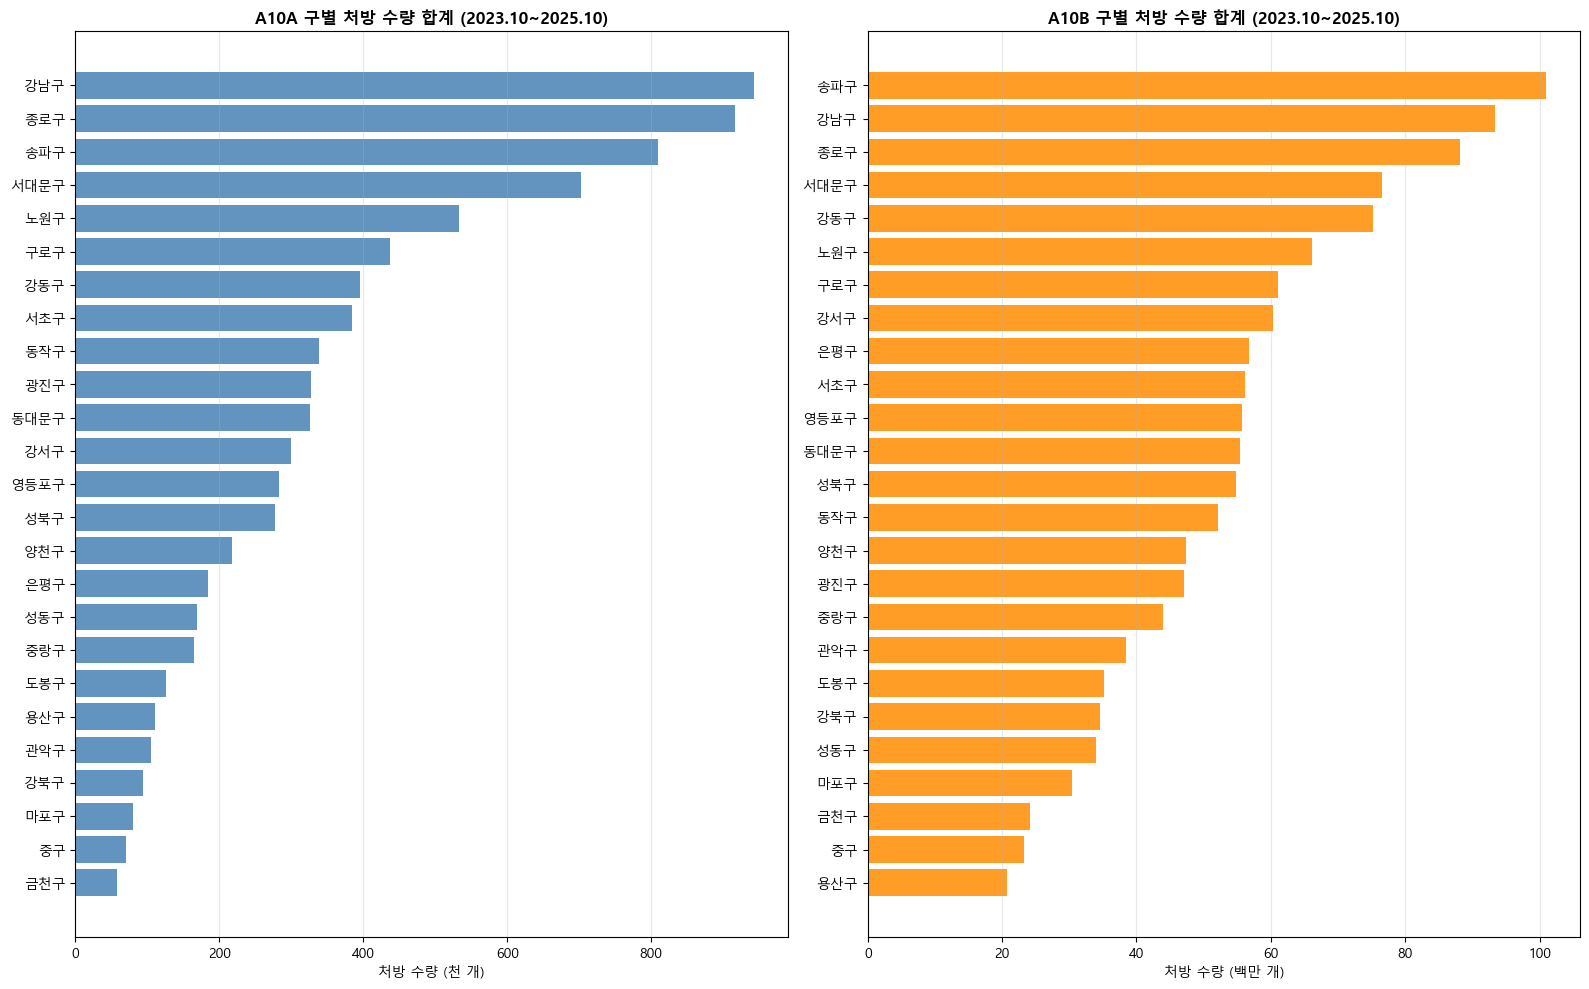

  저장: output/figures/02_gu_distribution.png


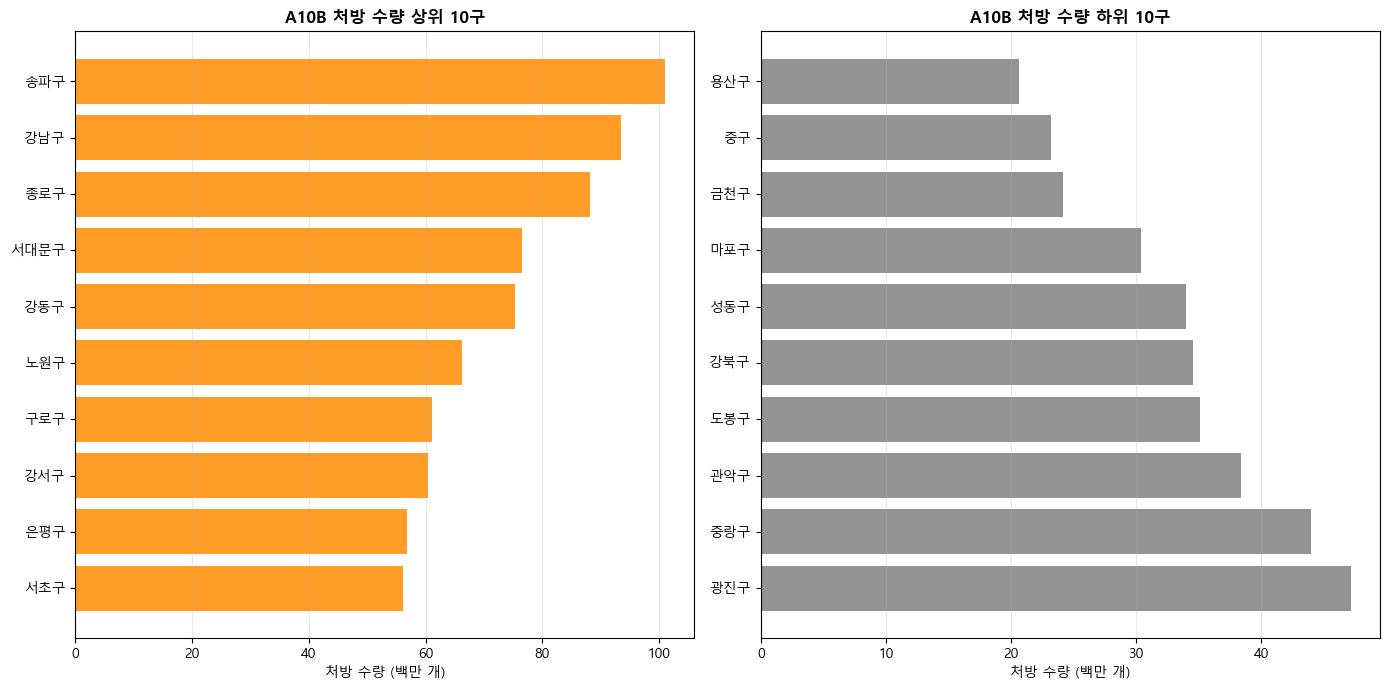

  저장: output/figures/02_gu_top_bottom.png


In [4]:
print("\n" + "=" * 60)
print("Step 3. 구별 처방량 분포 (서울 25개 구)")
print("=" * 60)

# 구별 전체 기간 합계
gu_a10a = df_a10a.groupby('시군구명칭')['수량'].sum().sort_values(ascending=False)
gu_a10b = df_a10b.groupby('시군구명칭')['수량'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

ax = axes[0]
ax.barh(gu_a10a.index[::-1], gu_a10a.values[::-1] / 1e3, color='steelblue', alpha=0.85)
ax.set_title('A10A 구별 처방 수량 합계 (2023.10~2025.10)', fontsize=12, fontweight='bold')
ax.set_xlabel('처방 수량 (천 개)')
ax.grid(True, axis='x', alpha=0.3)

ax = axes[1]
ax.barh(gu_a10b.index[::-1], gu_a10b.values[::-1] / 1e6, color='darkorange', alpha=0.85)
ax.set_title('A10B 구별 처방 수량 합계 (2023.10~2025.10)', fontsize=12, fontweight='bold')
ax.set_xlabel('처방 수량 (백만 개)')
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
path = f'{FIG_DIR}/02_gu_distribution.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f"  저장: {path}")

# 상위 10 / 하위 10 구 비교 (A10B)
sigungu_a10b = df_a10b.groupby('시군구명칭')['수량'].sum().sort_values(ascending=False).reset_index()
top10 = sigungu_a10b.head(10)
bot10 = sigungu_a10b.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].barh(top10['시군구명칭'][::-1], top10['수량'][::-1] / 1e6, color='darkorange', alpha=0.85)
axes[0].set_title('A10B 처방 수량 상위 10구', fontsize=12, fontweight='bold')
axes[0].set_xlabel('처방 수량 (백만 개)')
axes[0].grid(True, axis='x', alpha=0.3)

axes[1].barh(bot10['시군구명칭'], bot10['수량'] / 1e6, color='gray', alpha=0.85)
axes[1].set_title('A10B 처방 수량 하위 10구', fontsize=12, fontweight='bold')
axes[1].set_xlabel('처방 수량 (백만 개)')
axes[1].grid(True, axis='x', alpha=0.3)

plt.tight_layout()
path = f'{FIG_DIR}/02_gu_top_bottom.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f"  저장: {path}")

## Step 4. 인구 연계 분석
- 인구가 많을 수록 처방량이 많은가


Step 4. 인구 연계 분석
  병합 성공 시군구 수: 25


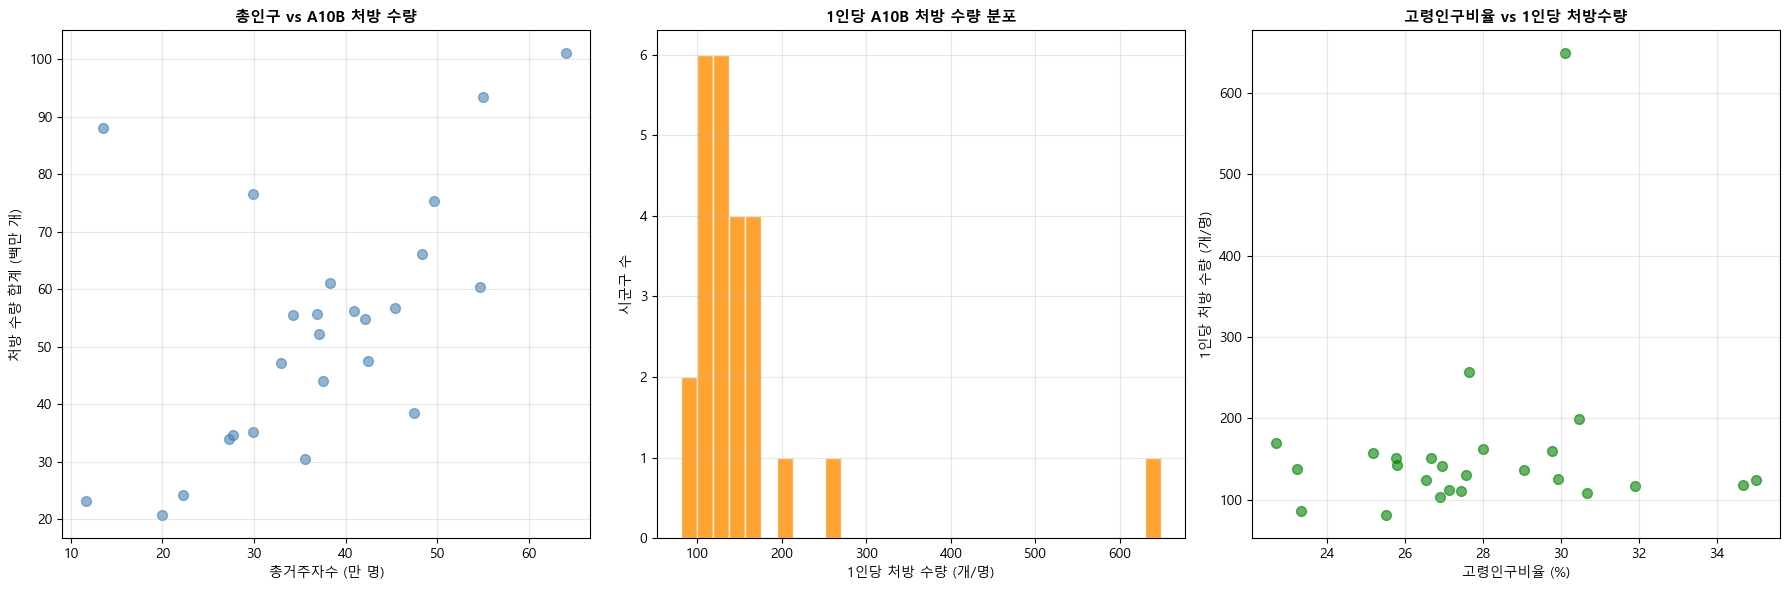

  저장: output/figures/03_population_vs_demand.png


In [5]:
print("\n" + "=" * 60)
print("Step 4. 인구 연계 분석")
print("=" * 60)

# 시군구별 전체 처방 수량 합계 (A10B)
sigungu_total = df_a10b.groupby('시군구명칭')['수량'].sum().reset_index()
sigungu_total.columns = ['시군구명칭', '처방수량']

# 인구 데이터 구명칭 추출: "서울특별시 강남구" -> "강남구"
# 구 단위 행만 필터 (코드 11자리 = 시군구 단위)
df_pop_gu = df_pop[df_pop['행정기관코드'].astype(str).str.len() == 10].copy()
df_pop_gu['시군구명칭'] = df_pop_gu['행정기관'].str.split().str[-1]

df_age_gu = df_age[df_age['행정기관코드'].astype(str).str.len() == 10].copy()
df_age_gu['시군구명칭'] = df_age_gu['행정기관'].str.split().str[-1]

# 병합
df_merged = pd.merge(sigungu_total, df_pop_gu[['시군구명칭', '총거주자수', '세대수', '세대당인구', '남여비율']], on='시군구명칭', how='inner')
df_merged = pd.merge(df_merged, df_age_gu[['시군구명칭', '고령인구비율']], on='시군구명칭', how='left')
df_merged['1인당처방수량'] = df_merged['처방수량'] / df_merged['총거주자수']
print(f"  병합 성공 시군구 수: {len(df_merged)}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 총인구 vs 처방수량 산점도
ax = axes[0]
ax.scatter(df_merged['총거주자수'] / 1e4, df_merged['처방수량'] / 1e6, alpha=0.6, color='steelblue', s=50)
ax.set_xlabel('총거주자수 (만 명)')
ax.set_ylabel('처방 수량 합계 (백만 개)')
ax.set_title('총인구 vs A10B 처방 수량', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)

# 1인당 처방수량 히스토그램
ax = axes[1]
ax.hist(df_merged['1인당처방수량'].dropna(), bins=30, color='darkorange', alpha=0.8, edgecolor='white')
ax.set_xlabel('1인당 처방 수량 (개/명)')
ax.set_ylabel('시군구 수')
ax.set_title('1인당 A10B 처방 수량 분포', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)

# 고령인구비율 vs 1인당처방수량
ax = axes[2]
plot_data = df_merged.dropna(subset=['고령인구비율', '1인당처방수량'])
ax.scatter(plot_data['고령인구비율'] * 100, plot_data['1인당처방수량'], alpha=0.6, color='green', s=50)
ax.set_xlabel('고령인구비율 (%)')
ax.set_ylabel('1인당 처방 수량 (개/명)')
ax.set_title('고령인구비율 vs 1인당 처방수량', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
path = f'{FIG_DIR}/03_population_vs_demand.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f"  저장: {path}")

## Step 5. 요양기관 종별 분석


Step 5. 요양기관 종별 분석


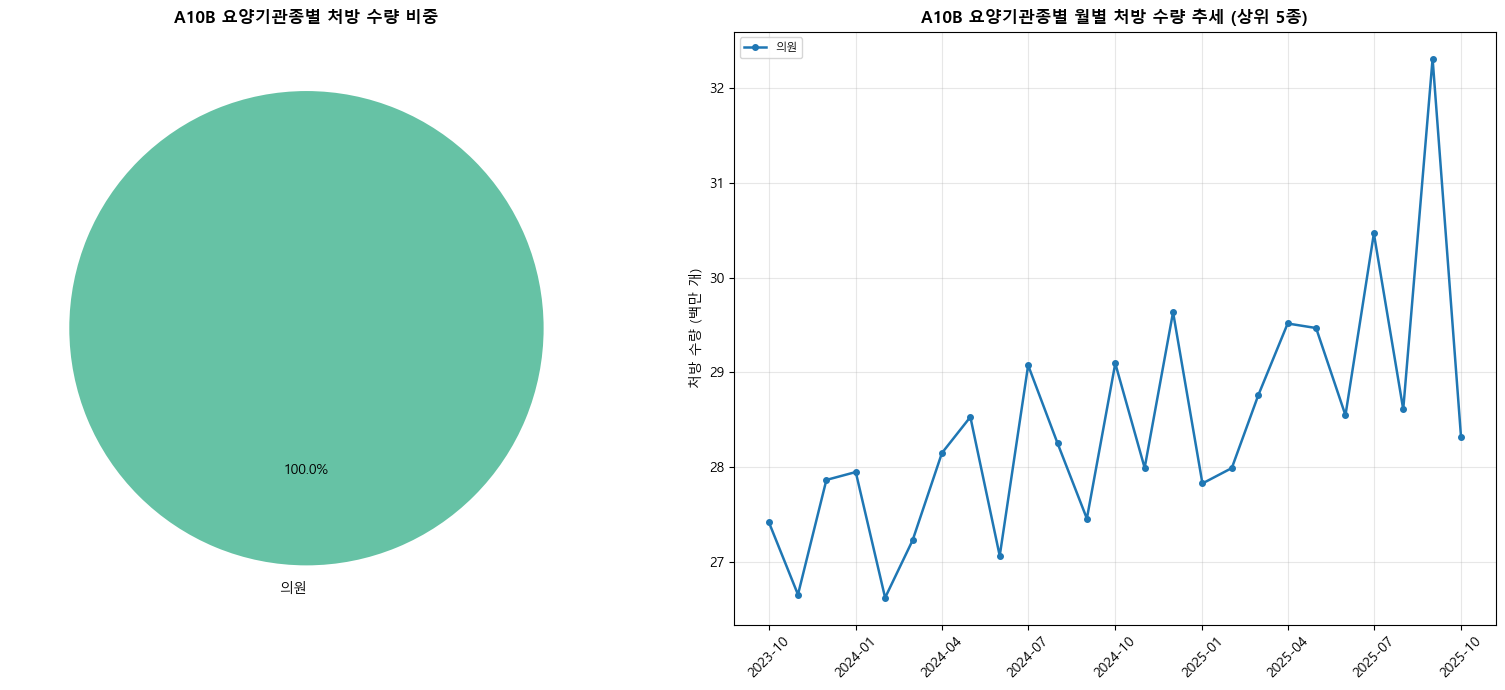

  저장: output/figures/04_institution_type.png


In [6]:
print("\n" + "=" * 60)
print("Step 5. 요양기관 종별 분석")
print("=" * 60)

# 요양기관별 전체 합계 (A10B)
yoy_total = df_a10b_yoy.groupby('요양기관종별')['수량'].sum().sort_values(ascending=False)
# '계' 제거
yoy_total = yoy_total[yoy_total.index != '계']

# 월별 요양기관별 추세 (상위 5종)
top_yoy = yoy_total.head(5).index.tolist()
yoy_monthly = df_a10b_yoy[df_a10b_yoy['요양기관종별'].isin(top_yoy)].groupby(
    ['기간_dt', '요양기관종별'])['수량'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 파이차트
ax = axes[0]
colors = plt.cm.Set2.colors
ax.pie(yoy_total.values[:6], labels=yoy_total.index[:6], autopct='%1.1f%%',
       colors=colors, startangle=90)
ax.set_title('A10B 요양기관종별 처방 수량 비중', fontsize=12, fontweight='bold')

# 월별 추세
ax = axes[1]
for yoy in top_yoy:
    data = yoy_monthly[yoy_monthly['요양기관종별'] == yoy]
    ax.plot(data['기간_dt'], data['수량'] / 1e6, marker='o', label=yoy, linewidth=1.8, markersize=4)
ax.set_title('A10B 요양기관종별 월별 처방 수량 추세 (상위 5종)', fontsize=12, fontweight='bold')
ax.set_ylabel('처방 수량 (백만 개)')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
path = f'{FIG_DIR}/04_institution_type.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f"  저장: {path}")

## Step 6. 상병별 분석


Step 6. 상병별 분석
  A10B 처방 상위 5 상병:
상병코드  상병명         
AE11  2형 당뇨병          4280922258
AI10  본태성(원발성) 고혈압     986943604
AE14  상세불명의 당뇨병        362842297
AI20  협심증              134715837
AN18  만성 콩팥병            98793325
Name: 수량, dtype: int64


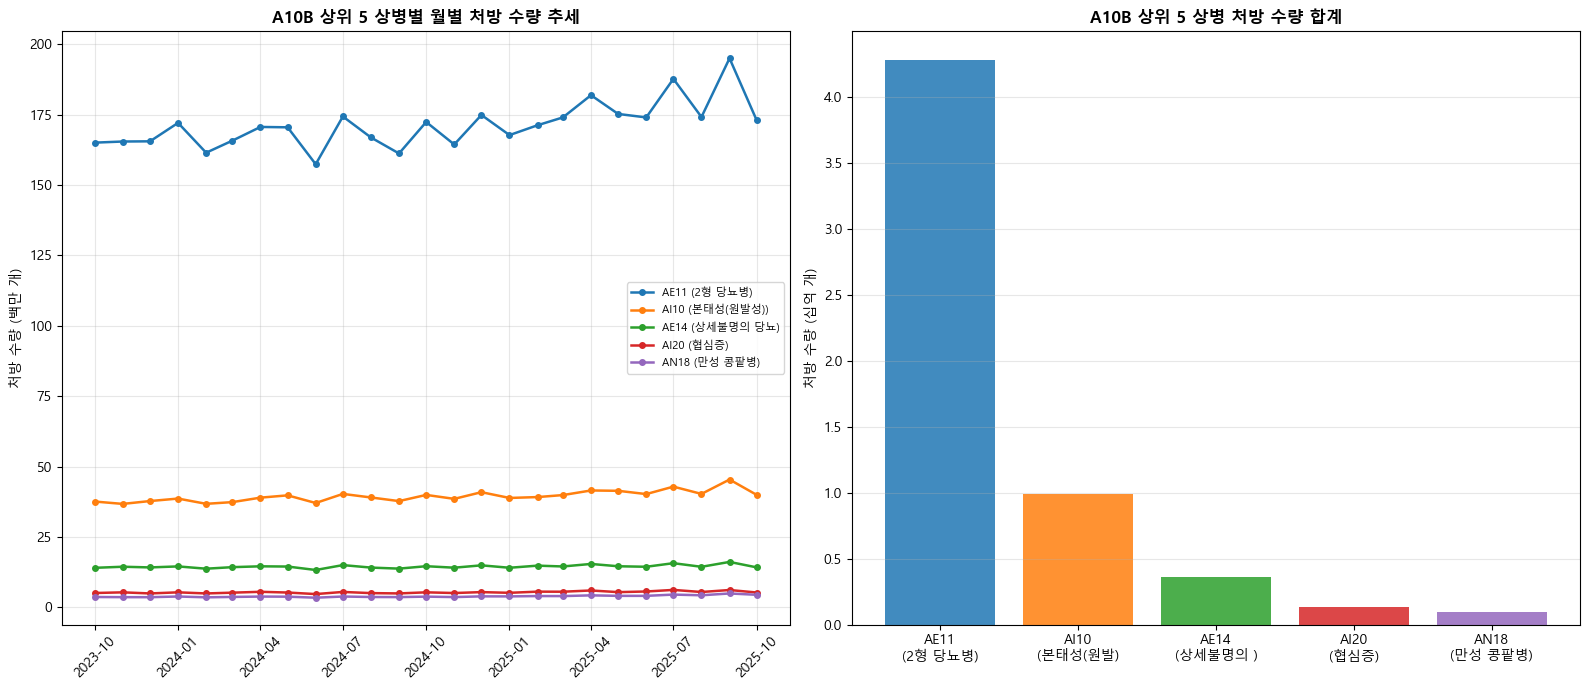

  저장: output/figures/05_disease_analysis.png


In [7]:
print("\n" + "=" * 60)
print("Step 6. 상병별 분석")
print("=" * 60)

# A10B 전체 기간 상위 5 상병
top_sb_a10b = df_a10b_sb.groupby(['상병코드', '상병명'])['수량'].sum().sort_values(ascending=False).head(5)
print(f"  A10B 처방 상위 5 상병:\n{top_sb_a10b}")

top_sb_codes = top_sb_a10b.index.get_level_values('상병코드').tolist()
top_sb_names = {row[0]: row[1] for row in top_sb_a10b.index}

sb_monthly = df_a10b_sb[df_a10b_sb['상병코드'].isin(top_sb_codes)].groupby(
    ['기간_dt', '상병코드', '상병명'])['수량'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 월별 추세
ax = axes[0]
colors_sb = plt.cm.tab10.colors
for i, code in enumerate(top_sb_codes):
    data = sb_monthly[sb_monthly['상병코드'] == code]
    label = f"{code} ({top_sb_names[code][:8]})"
    ax.plot(data['기간_dt'], data['수량'] / 1e6, marker='o', label=label,
            color=colors_sb[i], linewidth=1.8, markersize=4)
ax.set_title('A10B 상위 5 상병별 월별 처방 수량 추세', fontsize=12, fontweight='bold')
ax.set_ylabel('처방 수량 (백만 개)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# 상병별 총 점유율 막대
ax = axes[1]
labels_sb = [f"{c}\n({top_sb_names[c][:6]})" for c in top_sb_a10b.index.get_level_values('상병코드')]
ax.bar(labels_sb, top_sb_a10b.values / 1e9, color=colors_sb[:5], alpha=0.85)
ax.set_title('A10B 상위 5 상병 처방 수량 합계', fontsize=12, fontweight='bold')
ax.set_ylabel('처방 수량 (십억 개)')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
path = f'{FIG_DIR}/05_disease_analysis.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f"  저장: {path}")

## Step 7. 상관관계 분석


Step 7. 상관관계 분석


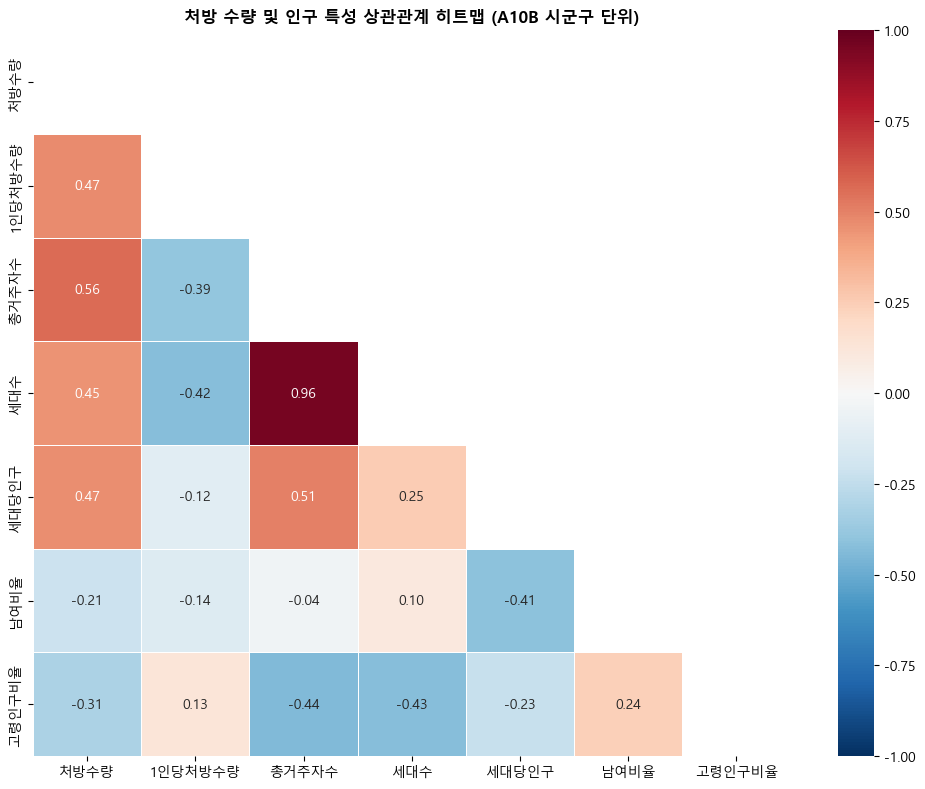

  저장: output/figures/06_correlation_heatmap.png

[완료] EDA 완료. 시각화 파일 목록:
  output/figures/01_monthly_trend.png
  output/figures/02_gu_distribution.png
  output/figures/02_gu_top_bottom.png
  output/figures/03_population_vs_demand.png
  output/figures/04_institution_type.png
  output/figures/05_disease_analysis.png
  output/figures/06_correlation_heatmap.png


In [8]:
print("\n" + "=" * 60)
print("Step 7. 상관관계 분석")
print("=" * 60)

# 시군구별 A10B 처방량 + 인구 특성
sigungu_all = df_a10b.groupby('시군구명칭').agg(
    처방수량=('수량', 'sum'),
    처방금액=('금액', 'sum')
).reset_index()

df_corr = pd.merge(sigungu_all, df_pop_gu[['시군구명칭', '총거주자수', '세대수', '세대당인구', '남여비율']], on='시군구명칭', how='inner')
df_corr = pd.merge(df_corr, df_age_gu[['시군구명칭', '고령인구비율']], on='시군구명칭', how='left')
df_corr['1인당처방수량'] = df_corr['처방수량'] / df_corr['총거주자수']

corr_cols = ['처방수량', '1인당처방수량', '총거주자수', '세대수', '세대당인구', '남여비율', '고령인구비율']
corr_matrix = df_corr[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('처방 수량 및 인구 특성 상관관계 히트맵 (A10B 시군구 단위)', fontsize=12, fontweight='bold')
plt.tight_layout()
path = f'{FIG_DIR}/06_correlation_heatmap.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f"  저장: {path}")

print("\n" + "=" * 60)
print("[완료] EDA 완료. 시각화 파일 목록:")
for f in sorted(os.listdir(FIG_DIR)):
    print(f"  {FIG_DIR}/{f}")
print("=" * 60)